## **Pedestrian Detection**

**What you will implement**
- Histogram of Oriented Gradients
- Linear Support Vector Machine (SVM)
- Multi-Scale Object Detector

**Implementation TODO** [70pt]
- **hog/gradient.py** [10pt]
    - `compute_gradient` [5pt]
    - `compute_magnitude_angle` [5pt]
- **hog/histogram.py** [5pt]
    - `compute_cell_histogram`
- **hog/descriptor.py** [10pt]
    - `HOGDescriptor.normalize_block` [5pt]
    - `HOGDescriptor.extract` [5pt]
- **svm/loss.py** [5pt]
    - `compute_hinge_loss`
- **svm/optimizer.py** [5pt]
    - `compute_gradient`
- **svm/classifier.py** [10pt]
    - `LinearSVM.train`
- **detection/pyramid.py** [5pt]
    - `generate_pyramid`
- **detection/sliding_window.py** [5pt]
    - `sliding_window`
- **detection/nms.py** [5pt]
    - `non_maximum_suppression`
- **detection/detector.py** [10pt]
    - `ObjectDetector.detect`


In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(441)

### **INRIA Person Detection dataset**
Set `dataset_dir` to the path of your downloaded data directory.

**Recommendation**: Download the dataset into the `data` folder and then unzip it.

In [4]:
from utils import dataset

dataset_dir = "data/INRIAPerson"
INRIAPerson = dataset.INRIAPersonDatasetHelper(dataset_dir)

In [5]:
# Load trainig data for SVM
pos_train, neg_train = INRIAPerson.get_data("train", max_samples=1000,
                                            shuffle=True, crops_per_image=2)
X_train = np.vstack([pos_train, neg_train])
y_train = np.hstack([np.ones(len(pos_train)), -np.ones(len(neg_train))])

# Random shuffle
random_indices = np.random.permutation(len(X_train))
X_train = X_train[random_indices]
y_train = y_train[random_indices]

Loading INRIA Person Dataset...

Data prepared:
- Positive samples: 1000
- Negative samples: 2000


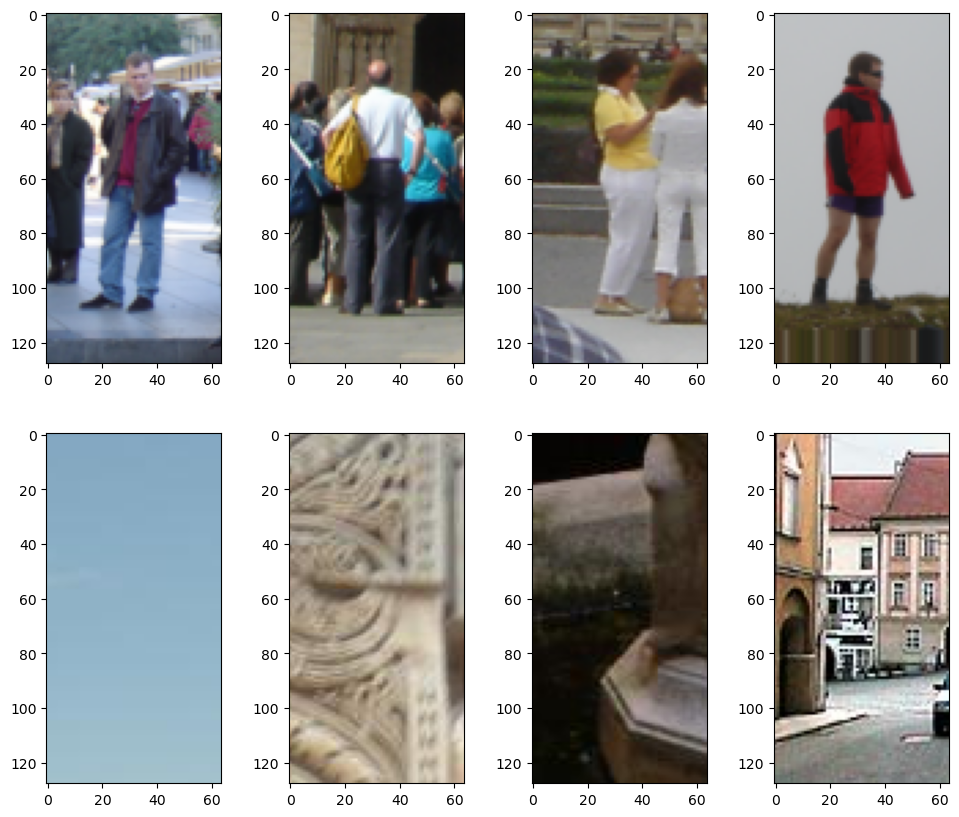

In [6]:
# Show some positive and negative images
# - above: positive images (containing a person)
# - below: negative images (no person)

N = 4

plt.figure(figsize=(12, 10))
for i in range(N):
    plt.subplot(2, N, i+1)
    plt.imshow(pos_train[i])
    plt.subplot(2, N, N+i+1)
    plt.imshow(neg_train[i])
    
plt.show()

### **Part 1: Histogram of Oriented Gradients (HOG)**

You should implement (see `hog/`):
- **gradient.py**: `compute_gradient`, `compute_magnitude_angle`
- **histogram.py**: `compute_cell_histogram`
- **descriptor.py**: `HOGDescriptor.normalize_block`, `HOGDescriptor.extract`

Once you have completed the implementation, execute the following code cell to verify its correctness.

In [7]:
import hog

In [8]:
hog_descriptor = hog.HOGDescriptor()

from tqdm import tqdm
# Extract HOG features from training images
hog_train = []
for img in tqdm(X_train, desc="extracting HOG features"):
    hog_train.append(hog_descriptor.extract(img))
    
hog_train = np.array(hog_train)

extracting HOG features: 100%|██████████| 3000/3000 [00:44<00:00, 68.11it/s]


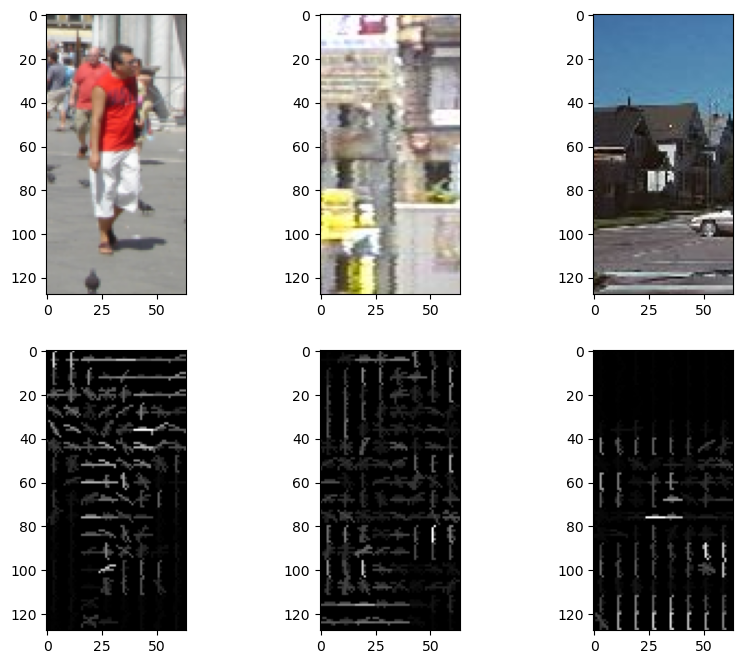

In [9]:
# Visualize HOG features for 3 samples

from utils.visualize import visualize_hog

plt.figure(figsize=(10, 8))
for i, sample_data in enumerate(X_train[:3]):
    cell_hists = hog_descriptor.get_cell_hists(sample_data)
    hog_img = visualize_hog(sample_data, cell_hists)
    
    plt.subplot(2, 3, i+1)
    plt.imshow(sample_data)
    plt.subplot(2, 3, i+4)
    plt.imshow(hog_img, cmap='gray')

plt.show()

### **Part 2: Linear SVM Classifier**

You should implement (see `svm/`):
- **gradient.py**: `compute_hinge_loss`
- **histogram.py**: `compute_gradient`
- **descriptor.py**: `LinearSVM.train`

Once you have completed the implementation, execute the following code cells to train the SVM using the HOG features in Part 1.

In [ ]:
import svm

# You can change hyperparameters below to achieve better performance
C = 1.0
learning_rate = 0.001
epochs = 100
batch_size = 32

In [27]:
linear_svm = svm.classifier.LinearSVM()
linear_svm.train(hog_train, y_train,
                 C=C,
                 learning_rate=learning_rate,
                 epochs=epochs,
                 batch_size=batch_size)

Epoch:  15%|█▌        | 15/100 [00:00<00:03, 25.48it/s]

Epoch 10/100, Loss: 0.3397


Epoch:  24%|██▍       | 24/100 [00:00<00:03, 24.04it/s]

Epoch 20/100, Loss: 0.3168


Epoch:  33%|███▎      | 33/100 [00:01<00:02, 23.74it/s]

...

Epoch 80/100, Loss: 0.3159


Epoch:  93%|█████████▎| 93/100 [00:03<00:00, 23.44it/s]

Epoch 90/100, Loss: 0.3162


Epoch: 100%|██████████| 100/100 [00:04<00:00, 23.93it/s]

Epoch 100/100, Loss: 0.3156
Training completed. Final loss: 0.3156


In [28]:
# Prepare test data for SVM
pos_test, neg_test = INRIAPerson.get_data("test", max_samples=500, crops_per_image=1)
X_test = np.vstack([pos_test, neg_test])
y_test = np.hstack([np.ones(len(pos_test)), -np.ones(len(neg_test))])

# random shuffle
random_indices = np.random.permutation(len(X_test))
X_test = X_test[random_indices]
y_test = y_test[random_indices]

Loading INRIA Person Dataset...

Data prepared:
- Positive samples: 500
- Negative samples: 453


In [29]:
# Extract HOG features from test data
hog_test = []
for img in tqdm(X_test, desc="test samples"):
    hog_test.append(hog_descriptor.extract(img))
hog_test = np.array(hog_test)

# Evaluate the SVM
acc = linear_svm.evaluate(hog_test, y_test)
print(f"(SVM) Test Accuracy: {acc * 100}%")

test samples: 100%|██████████| 953/953 [00:13<00:00, 70.09it/s]

(SVM) Test Accuracy: 62.43441762854145%


### **Part 3: Pedestrian Detection (HOG + SVM)**

You should implement (see `detection/`):
- **pyramid.py**: `generate_pyramid`
- **sliding_window.py**: `sliding_window`
- **detection/nms.py**: `non_maximum_suppression`
- **detection/detector.py**: `ObjectDetector.detect`

Once you have completed the implementation, execute the following code cells to verify the operation of the sliding window-based, multi-scale pedestrian detector using:
- The HOG feature descriptor from Part 1.
- The SVM classifier from Part 2.

In [14]:
import detection

# You can change hyperparameters below to obtain better results
scale_factor = 1.2
step_size = 8
score_threshold = 0.2
iou_threshold = 0.1

In [15]:
# To visually verify/confirm the results
num_detection_samples = 3
test_data = INRIAPerson.get_data_for_detection(max_samples=num_detection_samples,
                                               shuffle=True)

Loaded 3 image-annotation pairs for detection


In [16]:
PedDetector = detection.ObjectDetector(descriptor=hog_descriptor,
                                       classifier=linear_svm,
                                       scale_factor=scale_factor,
                                       step_size=step_size,
                                       score_threshold=score_threshold,
                                       iou_threshold=iou_threshold)

In [17]:
from utils import visualize

plt.figure(figsize=(16, 10))
# detect pedestrians in the test data
for i, data in enumerate(test_data):
    detect_result = PedDetector.detect(data["image"], verbose=True)
    img_bbox = visualize.draw_detection_comparison(data["image"], data["annotation"], [bbox[:4] for bbox in detect_result])
    plt.subplot(1, 3, (i+1))
    plt.imshow(img_bbox)

plt.show()

 40%|████      | 4/10 [00:14<00:22,  3.73s/it]


KeyboardInterrupt: 

<Figure size 1600x1000 with 0 Axes>